### Import required libraries

In [16]:
import cv2
import numpy as np
import pandas as pd
from pathlib import Path
import json
import time
import logging
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import mediapipe as mp
from PIL import Image

In [2]:
# Setting up plotting style
plt.style.use('default')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print(f"Mediapipe version: {mp.__version__}")

Mediapipe version: 0.10.21


### Configuration and directory setup

In [3]:
class FacialConfig:
    IMAGE_SIZE = (224, 224)
    FACE_DETECTION_CONFIDENCE = 0.5

    USE_GRAYSCALE = False

    # data augmentation settings
    ENABLE_AUGMENTATION = True
    AUGMENTATION_FACTOR = 6 # number of augmented versions per image

    # face detection settings
    FACE_PADDING = 20 # pixels to add around detected face

config = FacialConfig()

In [4]:
# Setting project directories
BASE_DIR = Path("./multimodal_facial_data")
RAW_IMAGES_DIR = BASE_DIR / "raw_facial"
PROCESSED_FACIAL_DIR = BASE_DIR / "processed_facial"
METADATA_DIR = BASE_DIR / "metadata"

for directory in [RAW_IMAGES_DIR, PROCESSED_FACIAL_DIR, METADATA_DIR]:
    directory.mkdir(parents=True, exist_ok = True)
    print(f"Created: {directory}")

Created: multimodal_facial_data/raw_facial
Created: multimodal_facial_data/processed_facial
Created: multimodal_facial_data/metadata


In [5]:
# Emotion mapping (7 emotions)
fer_emotions = {
    0: 'angry',
    1: 'disgust',
    2: 'fear',
    3: 'happy',
    4: 'sad',
    5: 'surprise',
    6: 'neutral'
}

# Emotion color mapping for visualization
emotion_colors = {
    'angry': 'red',
    'disgust': 'green',
    'fear': 'orange',
    'happy': 'yellow',
    'sad': 'blue',
    'surprise': 'pink',
    'neutral': 'gray'
}

In [6]:
# Set up logging
def get_project_logger(name):
    logger = logging.getLogger(name)
    if not logger.hasHandlers():
        handler = logging.StreamHandler()
        formatter = logging.Formatter('%(asctime)s - %(levelname)s - %(message)s')
        handler.setFormatter(formatter)
        logger.setLevel(logging.INFO)
    return logger

logger = get_project_logger('facial_collector')

print(f"Emotion categories: {list(fer_emotions.values())}")
print(f"Image size: {config.IMAGE_SIZE}")
print(f"Face detection confidence threshold: {config.FACE_DETECTION_CONFIDENCE}")
print(f"Base directory: {BASE_DIR}")

Emotion categories: ['angry', 'disgust', 'fear', 'happy', 'sad', 'surprise', 'neutral']
Image size: (224, 224)
Face detection confidence threshold: 0.5
Base directory: multimodal_facial_data


### Manual FER-2013 Dataset Setup

In [7]:
def setup_manual_fer2013():
    fer_base_path = RAW_IMAGES_DIR / "fer2013"

    fer_train_path = fer_base_path / "train"
    fer_test_path = fer_base_path / "test"

    dataset_info = {
        'format': 'folders',
        'samples': {},
        'emotion_found': set()
    }
    total_images = 0

    # checking training data
    if fer_train_path.exists():
        train_total = 0
        for emotion_folder in fer_train_path.iterdir():
            if emotion_folder.is_dir() and emotion_folder.name in fer_emotions.values():
                # Count images
                images = (list(emotion_folder.glob("*.png")) +
                          list(emotion_folder.glob("*.jpg")) +
                          list(emotion_folder.glob("*.jpeg")))
                dataset_info['samples'][f"train_{emotion_folder.name}"] = len(images)
                dataset_info['emotion_found'].add(emotion_folder.name)
                train_total += len(images)
                total_images += len(images)
                print(f" {emotion_folder.name}: {len(images)} images")

        print(f"Total train images: {train_total}")

    
    # checking testing data
    if fer_test_path.exists():
        test_total = 0
        for emotion_folder in fer_test_path.iterdir():
            if emotion_folder.is_dir() and emotion_folder.name in fer_emotions.values():
                # counting images
                images = (list(emotion_folder.glob("*.png")) +
                          list(emotion_folder.glob("*.jpg")) +
                          list(emotion_folder.glob("*.jpeg")))
                
                dataset_info['samples'][f"test_{emotion_folder.name}"] = len(images)
                dataset_info['emotion_found'].add(emotion_folder.name)
                test_total += len(images)
                total_images += len(images)
                print(f" {emotion_folder.name}: {len(images)} images")

        print(f"Total test images: {test_total}")

    dataset_info['total'] = total_images
    dataset_info['base_path'] = fer_base_path

    missing_emotions = set(fer_emotions.values()) - dataset_info['emotion_found']
    if missing_emotions:
        print(f"Missing emotions: {sorted(missing_emotions)}")

    return dataset_info

In [8]:
fer_dataset_info = setup_manual_fer2013()
print(f"Found {fer_dataset_info['total']} images")
print(f"Distribution: {fer_dataset_info['samples']}")
fer_ready = True
fer_format = 'folders'
fer_base_path = fer_dataset_info['base_path']

 happy: 7215 images
 disgust: 436 images
 angry: 3995 images
 surprise: 3171 images
 neutral: 4965 images
 fear: 4097 images
 sad: 4830 images
Total train images: 28709
 happy: 1774 images
 disgust: 111 images
 angry: 958 images
 surprise: 831 images
 neutral: 1233 images
 fear: 1024 images
 sad: 1247 images
Total test images: 7178
Found 35887 images
Distribution: {'train_happy': 7215, 'train_disgust': 436, 'train_angry': 3995, 'train_surprise': 3171, 'train_neutral': 4965, 'train_fear': 4097, 'train_sad': 4830, 'test_happy': 1774, 'test_disgust': 111, 'test_angry': 958, 'test_surprise': 831, 'test_neutral': 1233, 'test_fear': 1024, 'test_sad': 1247}


### Mediapipe face detection initialization

In [9]:
mp_face_detection = mp.solutions.face_detection
mp_face_mesh = mp.solutions.face_mesh
mp_drawing = mp.solutions.drawing_utils
mp_drawing_styles = mp.solutions.drawing_styles

In [10]:
# Testing mediapipe with sample image
def test_mediapipe_detection():
    test_image = np.random.randint(0, 255, (480, 640, 3), dtype=np.uint8)

    try:
        with mp_face_detection.FaceDetection(
            model_selection=0,
            min_detection_confidence = 0.5
        ) as face_detection:
            
            # converting to RGB
            rgb_image = cv2.cvtColor(test_image, cv2.COLOR_BGR2RGB)
            results = face_detection.process(rgb_image)

            if results.detections:
                print(f"Found {len(results.detections)} faces")
            else:
                print("No faces found!")
        
        return True
    
    except Exception as e:
        print(f"MediaPipe error: {e}")
        return False
    
# testing mediapipe
mediapipe_status = test_mediapipe_detection()

if mediapipe_status:
    print(f"Configuration:")
    print(f"Detection confidence: {config.FACE_DETECTION_CONFIDENCE}")
    print(f"Target image size: {config.IMAGE_SIZE}")
    print(f"Face padding: {config.FACE_PADDING}px")

else:
    print("Mediapipe failed!")

Found 1 faces
Configuration:
Detection confidence: 0.5
Target image size: (224, 224)
Face padding: 20px


I0000 00:00:1761024847.097450    1010 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1761024847.143594    1795 gl_context.cc:369] GL version: 3.2 (OpenGL ES 3.2 Mesa 25.0.7-0ubuntu0.24.04.2), renderer: llvmpipe (LLVM 20.1.2, 256 bits)
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1761024847.156927    1731 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


### Face Detection & Cropping experiment

In [11]:
def detect_and_crop_face(image, show_visualization=True):
    try:
        # Coverting BGR to RGB
        rgb_image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        # Create face detection instance
        with mp_face_detection.FaceDetection(
            model_selection = 0, # 0 for close range, 1 for far range
            min_detection_confidence = config.FACE_DETECTION_CONFIDENCE
        ) as face_detection:
            
            # Detect faces
            results = face_detection.process(rgb_image)

            if results.detections:
                detection = results.detections[0]
                bboxC = detection.location_data.relative_bounding_box

                # getting image dimensions
                h, w, _ = image.shape

                # Convert relative coordinates to pixel coordinates
                x = int(bboxC.xmin * w)
                y = int(bboxC.ymin * h)
                width = int(bboxC.width * w)
                height = int(bboxC.height * h)

                # applying padding
                padding = config.FACE_PADDING
                x = max(0, x - padding)
                width = min(w - x, width + 2 * padding)
                height = min(h - y, height + 2 * padding)

                # cropping face region
                face = image[y: y + height, x: x + width]

                # resize to standard size
                face_resized = cv2.resize(face, config.IMAGE_SIZE)

                # visualization
                if show_visualization:
                    fig, axes = plt.subplots(1, 3, figsize = (18, 6))

                    img_with_box = image.copy()
                    cv2.rectangle(img_with_box, (x, y), (x + width, y), (0, 255, 0), 2)
                    axes[0].imshow(cv2.cvtColor(img_with_box, cv2.COLOR_BGR2RGB))
                    axes[0].set_title("Original  with Detections")
                    axes[0].axis('off')

                    # cropped face
                    axes[1].imshow(cv2.cvtColor(face, cv2.COLOR_BGR2RGB))
                    axes[1].set_title(f'Cropped face ({face.shape[1]}x{face.shape[0]})')
                    axes[1].axis('off')

                    # resized face
                    axes[2].imshow(cv2.cvtColor(face_resized, cv2.COLOR_BGR2RGB))
                    axes[2].set_title(f'Resized face ({config.IMAGE_SIZE[0]}x{config.IMAGE_SIZE[1]})')
                    axes[2].axis('off')

                    plt.tight_layout()
                    plt.show()

                return face_resized
            else:
                if show_visualization:
                    print("No face detected in image.")
                return None
            
    except Exception as e:
        print(f"Face detection error: {e}")
        return None




I0000 00:00:1761024847.200017    1010 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1761024847.209194    1830 gl_context.cc:369] GL version: 3.2 (OpenGL ES 3.2 Mesa 25.0.7-0ubuntu0.24.04.2), renderer: llvmpipe (LLVM 20.1.2, 256 bits)
W0000 00:00:1761024847.213791    1825 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


Testing face detection !!
Using sample: Training_21410769.jpg (happy)


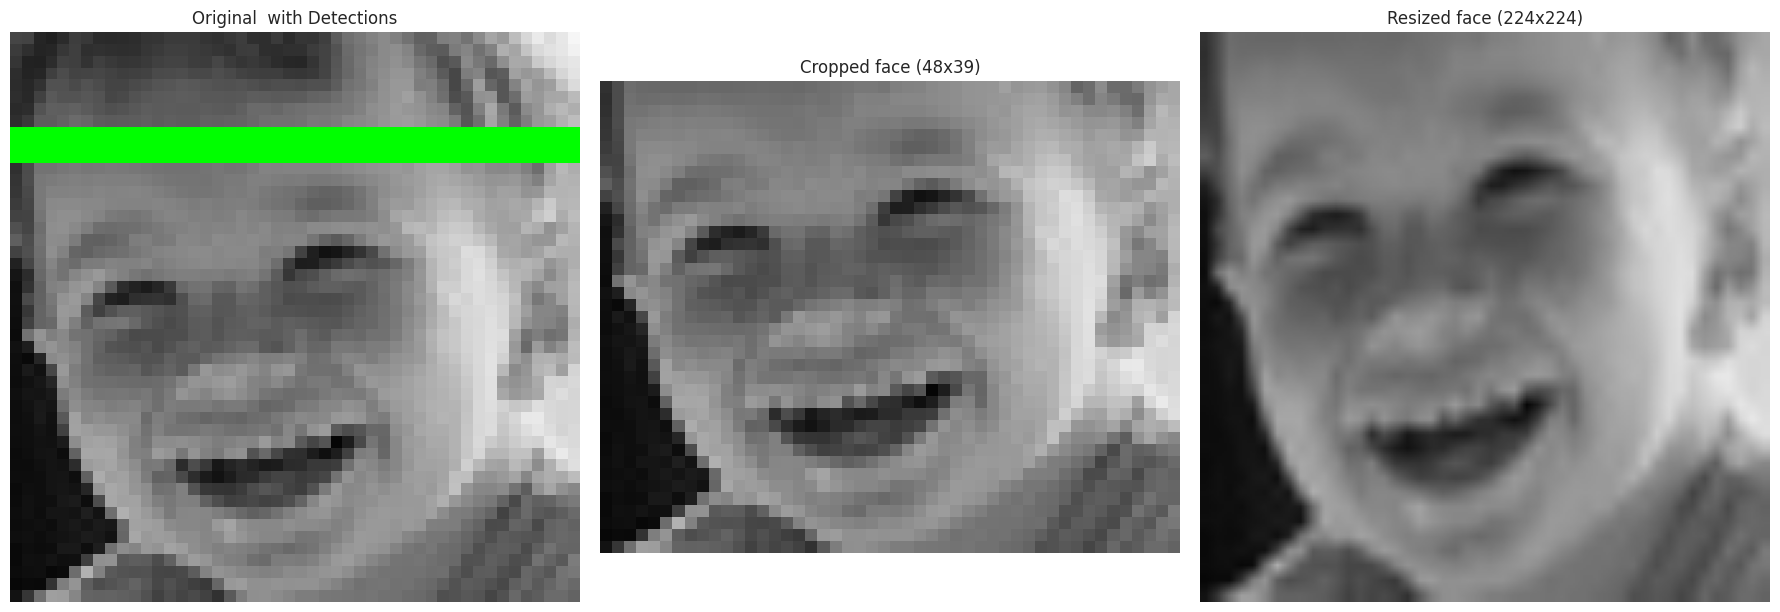

Face Detection successful
original size : (48, 48, 3)
Final size : (224, 224, 3)


In [12]:
# Testing face detection with a sample image
print("Testing face detection !!")

train_path = fer_base_path / "train"
sample_image_path = None

for emotion_folder in train_path.iterdir():
    if emotion_folder.is_dir():
        images = list(emotion_folder.glob("*.jpg")) + list(emotion_folder.glob("*.png"))
        if images:
            sample_image_path = images[0]
            emotion_name = emotion_folder.name
            break

if sample_image_path:
    print(f"Using sample: {sample_image_path.name} ({emotion_name})")

    # load and test
    sample_image = cv2.imread(str(sample_image_path))
    if sample_image is not None:
        cropped_face = detect_and_crop_face(sample_image, show_visualization=True)
        
        if cropped_face is not None:
            print(f"Face Detection successful")
            print(f"original size : {sample_image.shape}")
            print(f"Final size : {cropped_face.shape}")
        else:
            print("face detection failed!")
        
    else:
        print("could not load sample image!")

else:
    print("No sample image found")

### Facial Landmark Extraction experiment

In [13]:
# using mediapipe face Mesh
def extract_facial_landmark(face_image, show_visualization=True):
    try:
        rgb_image = cv2.cvtColor(face_image, cv2.COLOR_BGR2RGB)

        # Create face mesh instance
        with mp_face_mesh.FaceMesh(
            static_image_mode = True,
            max_num_faces = 1,
            refine_landmarks = True,
            min_detection_confidence = 0.5
        ) as face_mesh:
            
            results = face_mesh.process(rgb_image)

            if results.multi_face_landmarks:
                landmarks = []
                face_landmarks = results.multi_face_landmarks[0]

                for landmark in face_landmarks.landmark:
                    # store x, y, z coordinates
                    landmarks.extend([landmark.x, landmark.y, landmark.z])
                
                landmark_array = np.array(landmarks)

                # visualization
                if show_visualization:
                    annotated_image = face_image.copy()
                    mp_drawing.draw_landmarks(
                        image = annotated_image,
                        landmark_list = face_landmarks,
                        connections = mp_face_mesh.FACEMESH_TESSELATION,
                        landmark_drawing_spec = None,
                        connection_drawing_spec = mp_drawing_styles.get_default_face_mesh_tesselation_style()
                    )

                    # display 
                    fig, axes = plt.subplots(1, 2, figsize = (12, 6))
                    axes[0].imshow(cv2.cvtColor(face_image, cv2.COLOR_BGR2RGB))
                    axes[0].set_title('Original Face')
                    axes[0].axis('off')

                    axes[1].imshow(cv2.cvtColor(annotated_image, cv2.COLOR_BGR2RGB))
                    axes[1].set_title('With 478 facial landmarks')
                    axes[1].axis('off')

                    plt.tight_layout()
                    plt.show()

                    print("Landmark Statistics:")
                    print("Total landmarks: 478 and coordinates per landmark: 3(x, y, z)")
                    print(f"Total features: {len(landmark_array)}")
                    print(f"Shape: {landmark_array.shape}")
                    print(f"Sample values: {landmark_array[:9]}")  # first 3 landmarks

                return landmark_array

            else:
                if show_visualization:
                    print("No facial landmarks detected")
                return None
    
    except Exception as e:
        print(f" Error extracted landmarks: {e}")
        return None


 Using happy sample: Training_21410769.jpg


I0000 00:00:1761024847.471500    1010 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1761024847.479137    1847 gl_context.cc:369] GL version: 3.2 (OpenGL ES 3.2 Mesa 25.0.7-0ubuntu0.24.04.2), renderer: llvmpipe (LLVM 20.1.2, 256 bits)
W0000 00:00:1761024847.486063    1841 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
I0000 00:00:1761024847.499124    1010 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1761024847.507868    1876 gl_context.cc:369] GL version: 3.2 (OpenGL ES 3.2 Mesa 25.0.7-0ubuntu0.24.04.2), renderer: llvmpipe (LLVM 20.1.2, 256 bits)
W0000 00:00:1761024847.511812    1848 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1761024847.531594    1851 inference_feedback_manager.cc:114] Feedback manager requ

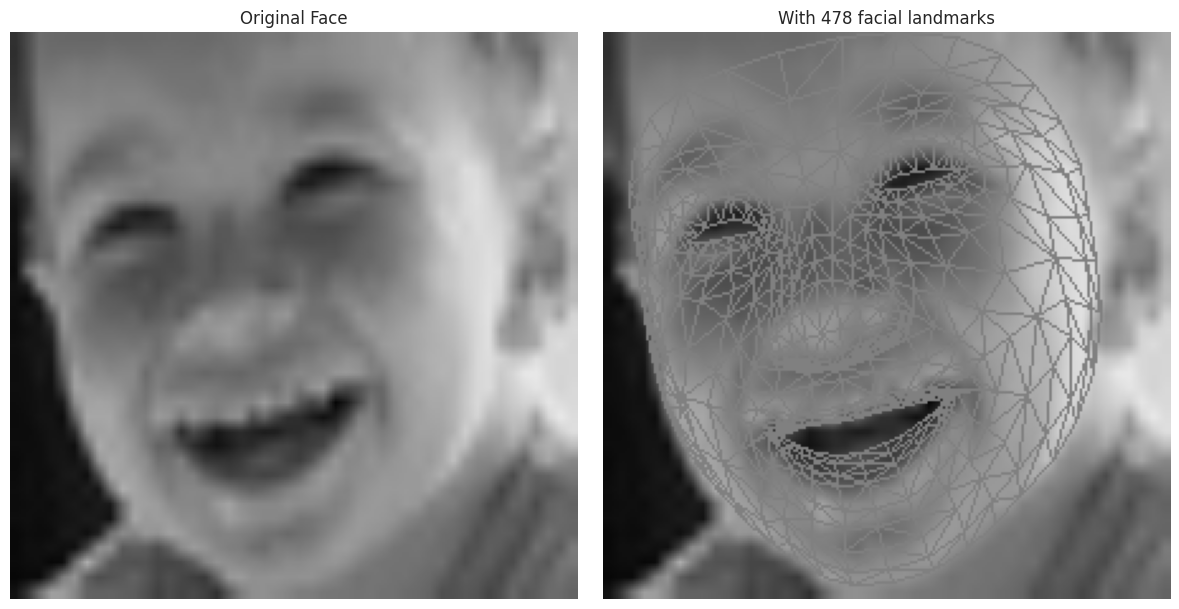

Landmark Statistics:
Total landmarks: 478 and coordinates per landmark: 3(x, y, z)
Total features: 1434
Shape: (1434,)
Sample values: [ 0.42492539  0.66254818 -0.10308881  0.39357334  0.5703944  -0.18841229
  0.41347602  0.59431958 -0.10881869]
Successfully extracted 1434 landmark coordinates.


In [14]:
# Testing landmark extraction 
train_path = fer_base_path / 'train'

happy_path = train_path / 'happy'
if happy_path.exists():
    images = list(happy_path.glob("*.jpg")) + list(happy_path.glob("*.png"))
    if images:
        sample_path = images[0]
        print(f" Using happy sample: {sample_path.name}")

        sample_image = cv2.imread(str(sample_path))
        if sample_image is not None:
            cropped_face = detect_and_crop_face(sample_image, show_visualization=False)

            if cropped_face is not None:
                landmarks = extract_facial_landmark(cropped_face, show_visualization=True)

                if landmarks is not None:
                    print(f"Successfully extracted {len(landmarks)} landmark coordinates.")
                else:
                    print("Landmark extraction failed")
            else:
                print("face detection failed")
        else:
            print("Can't load sample image.")

    else:
        print("Happy image not found")

else:
    print("Folder not found!")


### Image augmentation

In [15]:
def augment_facial_image(image):
    augmented = []

    # original image
    augmented.append(('original', image))

    # horizontal flip
    flipped = cv2.flip(image, 1)
    augmented.append(('flipped', flipped))

    # brightness adjustments
    bright = np.clip(image * 1.2, 0, 1) 
    augmented.append(('bright', bright))

    dark = np.clip(image * 0.8, 0, 1)
    augmented.append(('dark', dark))

    # Contrast adjustment
    contrast = np.clip((image - 0.5) * 1.3 + 0.5, 0, 1)
    augmented.append(('contrast', contrast))

    # Slight rotation
    h, w = image.shape[:2]
    center = (w // 2, h//2)

    # Rotate +5 degree
    M = cv2.getRotationMatrix2D(center, 5, 1.0)
    rotated_pos = cv2.warpAffine(image, M, (w, h))

    # Rotate -5 degree
    M = cv2.getRotationMatrix2D(center, -5, 1.0)
    rotated_neg = cv2.warpAffine(image, M, (w, h))
    augmented.append(('rotated_-5', rotated_neg))

    # Gaussian noise
    noise = np.random.normal(0, 0.02, image.shape)
    noisy = np.clip(image + noise, 0, 1)
    augmented.append(('noisy', noisy))

    # Gaussian blur
    blurred = cv2.GaussianBlur(image, (3, 3), 0)
    augmented.append(('blurred', blurred))

    return augmented

In [ ]:
# Testing augmentation
train_path = fer_base_path / "train"
angry_path = train_path / "angry"

images = list(angry_path.glob("*.jpg")) + list(angry_path.glob("*.png"))
sample_path = images[0]
print(f"Using angry sample: {sample_path.name}")

# Load and preprocess
image = cv2.imread(str(sample_path))
if image is not None:
    image_resized = cv2.resize(image, config.IMAGE_SIZE)
    image_normalized = image_resized.astype(np.float32) / 255.0

    # Apply augmentations
    augmented_images = augment_facial_image(image_normalized)

    # visualization of augmentations
    n_augmentation = len(augmented_images)
    cols = 3
    rows = (n_augmentation + cols - 1) // 3
